In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Utils

In [2]:
def z_score_normalization(X):                              
    mu = np.mean(X, axis=0)                                                     
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma                                                                                               
    return X_norm, mu, sigma                               

# Step 1: Feature Preparation - cleaning,scaling engineering

## 1. Load data

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 2. EDA

#### 2.1 clean non required fields

In [4]:
df_cleaned = df.drop(columns="customerID")

#### 2.2 fix problematic feature columns

In [5]:
## TotalCharges is str due to some missing values so first fixing that

df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'], errors='coerce').fillna(0)

In [6]:
df_cleaned['SeniorCitizen'] = df_cleaned['SeniorCitizen'].map({1:'Yes', 0: 'No'})
df_cleaned['Churn'] = df_cleaned['Churn'].map({'Yes':1,'No': 0})

## 3. Feature/Target split

In [7]:
y = df_cleaned['Churn']
X = df_cleaned.drop(columns="Churn")

In [8]:
print(X.shape, y.shape)

(7043, 19) (7043,)


## 4. Preprocessing

In [9]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'str']).columns

#### 4.1 One Hot Encoding - category columns

In [10]:
X_encoded = pd.get_dummies(X,columns=cat_cols,drop_first=True,dtype="int")

#### 4.2 Feature Scaling

Do normalization for train and test data seperately, as we can't use the test data to compute mean and std as it will lead to data leakage and will give unrealistic better results

##### 4.2.1 Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,y,test_size=0.2,random_state=42,stratify=y
)

##### 4.2.2 Feature Scaling (Normalization)

In [12]:
X_train_norm,mu,sigma = z_score_normalization(X_train)
X_test_norm = (X_test-mu)/sigma

In [13]:
type(X_train_norm)

pandas.DataFrame

# Step 2 : Model Making

## 1. Implementaion of required function in the model

#### 1.1 Sigmoid function - for predicting probability values between 0-1 

In [14]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

##### 1.1.1 Plotting Sigmoid for testing validity

0.9999546021312976 4.5397868702434395e-05


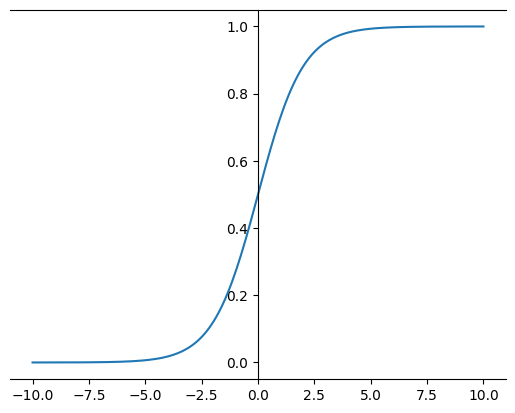

In [15]:
z = np.linspace(-10,10,200)
g_z = sigmoid(z)
print(max(g_z),min(g_z))

fig, ax = plt.subplots()
ax.plot(z, g_z)
ax.spines['left'].set_position('center')
ax.spines['right'].set_color('none')

the sigmoid values are lying between 0 - 1 so its a valid function

#### 1.2 Cost function for Logistic Regression

In [16]:
def compute_cost(X,y,w,b):
    eps = 1e-15    
    z = np.dot(X,w) + b         # (rows,)
    g = sigmoid(z)               # (rows,)
    # to prevent log(0)/log(1) which is inf, we are clipping a small number so log never got 0/1
    g = np.clip(g, eps, 1-eps)
    cost = -np.mean(y*np.log(g) + (1-y)*np.log(1-g))

    return(cost)

##### 1.2.1 Testing cost function for log(0)

In [17]:
compute_cost(X_train_norm,y_train,(np.zeros(X_test_norm.shape[1])), 0)

np.float64(0.6931471805599453)

#### 1.3 Compute Gradient and Gradient Descent

##### 1.3.1 Compute Gradient

In [18]:
def compute_gradient(X,y,w,b):
    m,n = X.shape
    
    dj_dw = np.zeros(n,)
    dj_db = 0
    
    err = sigmoid(np.dot(X,w) + b) - y        #(m,)
    dj_dw = (1/m) * np.dot(X.T, err)
    dj_db = (1/m) * np.sum(err)
    return dj_dw, dj_db

##### 1.3.2 Gradient descent

In [19]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w = w_init.copy() 
    b = b_init
    cost_history = []
    for i in range(num_iters):
        dw, db = compute_gradient(X, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        if i % 1000 == 0:
            cost = compute_cost(X, y, w, b)
            print(cost)
            cost_history.append(cost)
    return w, b, cost_history

## 2. Model training

In [20]:
n = X_train_norm.shape[1]
w_init = np.zeros(n)
b_init = 0.0

w, b, cost_history = gradient_descent(
    X_train_norm, y_train, w_init, b_init, alpha=0.3, num_iters=10000
)

0.6258640427354945
0.4132409732010122
0.4129077395442335
0.4128305770412082
0.4127926299340903
0.4127625422414534
0.41273537415387984
0.41271023079899305
0.41268686102349544
0.4126651235644093


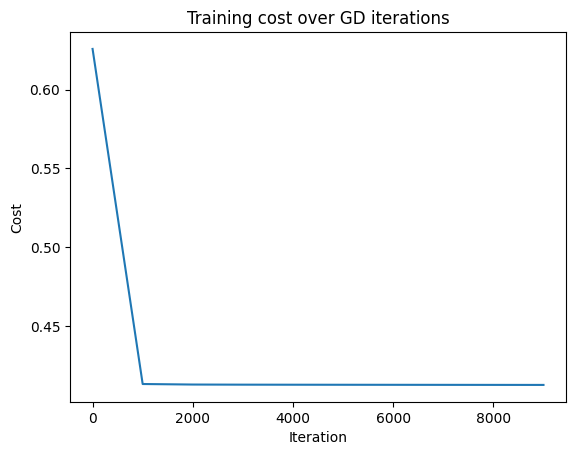

In [21]:
plt.plot(range(0, 10000,1000), cost_history)
plt.xlabel("Iteration"); plt.ylabel("Cost"); plt.title("Training cost over GD iterations")
plt.show()

In [22]:
cost_history[::100]

[np.float64(0.6258640427354945)]

In [23]:
z_test = X_test_norm @ w + b
p_test = sigmoid(z_test)
y_pred_scratch = (p_test >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
print(f"Accuracy:  {accuracy_score(y_test, y_pred_scratch):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_scratch):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, p_test):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_scratch))

Accuracy:  0.8055
F1:        0.6040
ROC-AUC:   0.8424
Confusion matrix:
[[926 109]
 [165 209]]


### Model Comparison

| Metric          | Sklearn Model | Numpy/Pandas Model |
|-----------------|--------------|--------------------|
| Accuracy        | 0.8055       | 0.7871             |
| F1 Score        | 0.6040       | 0.4700             |
| ROC-AUC         | 0.8420       | 0.7881             |

### Confusion Matrices

**Sklearn Model**
```
[[926 109]
 [165 209]]
```

**Numpy/Pandas Model**
```
[[976  59]
 [241 133]]
```


In [24]:
from sklearn.linear_model import LogisticRegression
                                                     
# Fit unregularized sklearn on the EXACT same normalized matrix
sk_lr = LogisticRegression(C=1e10, max_iter=100000, fit_intercept=True, solver='lbfgs')                                     
sk_lr.fit(X_train_norm, y_train)                                                       
                                                                                                                            
p_sk = sk_lr.predict_proba(X_test_norm)[:, 1]              
                                                                                                                            
# Use your best converged run — the α=5 weights, ideally   
abs_diff = np.abs(p_test - p_sk)                                                                                            
print(f"Max abs diff: {abs_diff.max():.6f}")               
print(f"Mean abs diff: {abs_diff.mean():.6f}")                                                                              

Max abs diff: 0.059088
Mean abs diff: 0.006646


In [25]:
print(f"type(mu):    {type(mu)}")                          
print(f"type(sigma): {type(sigma)}")                                                                                        
print(f"\nmu values (first 5):    {list(mu[:5]) if hasattr(mu, '__iter__') else mu}")
print(f"sigma values (first 5): {list(sigma[:5]) if hasattr(sigma, '__iter__') else sigma}")

type(mu):    <class 'pandas.Series'>
type(sigma): <class 'pandas.Series'>

mu values (first 5):    [32.48509052183174, 64.92996095136671, 2299.33468228612, 0.5028399006034788, 0.16329428470003549]
sigma values (first 5): [24.56656301538815, 30.135430576006627, 2279.001996496138, 0.49999193489951654, 0.3696339558053876]
